In [1]:
import tensorflow as tf 

gpus = tf.config.list_physical_devices("GPU")

print(gpus)

2025-02-22 11:47:08.167559: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-22 11:47:08.193638: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-22 11:47:08.193657: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-22 11:47:08.194402: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-22 11:47:08.199852: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import sys
sys.path.append('../tools_')

from tools import *

In [3]:
import sys, os


from scipy.io import loadmat
import numpy as np
from random import randint
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import default_rng
import scipy.io
import h5py
from scipy import signal as sigproc
from scipy.interpolate import interp1d
from math import floor
from scipy import signal
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import tensorflow as tf
import random
import math
from sklearn.metrics import mean_squared_error
from fastdtw import fastdtw
import time
import keras
from keras import models, layers
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras import datasets, layers, models, losses, Model
from generators import *
from numpy import reshape
import matplotlib.image
from scipy.io import savemat
#from plots import *
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from datetime import time


In [4]:
data_short_dir = "/home/alumnos/mburgosc/tfg/egm_reconstruction/Data_short"
egms_all_models = load_egms_df(data_short_dir)

data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']


In [5]:
print(egms_all_models)

                              id  \
0   Simulation_01_210209_001_002   
1             LA_RSPV_CAF_150115   
2   Simulation_01_200428_001_001   
3   Simulation_01_201223_001_002   
4   Simulation_01_190619_001_004   
5   Simulation_01_190502_001_004   
6                 RA_RAFW_140807   
7                  RA_RAA_141230   
8   Simulation_01_200316_001_  1   
9               TwoRotors_181219   
10            RA_RAFW_SAF_140730   
11  Simulation_01_200212_001_  4   

                                            AF_signal  
0   [[9.479828179102282e-14, 0.04080228461795585, ...  
1   [[7.387776530722087, 9.094867906767199, 10.800...  
2   [[0.8807414426522221, 1.015404814148348, 0.963...  
3   [[4.24492593645743, 4.6424979299912765, 5.0315...  
4   [[-50.648764509652416, -48.25332554580271, -44...  
5   [[-61.093924858397685, -56.059614688222744, -5...  
6   [[-15.990956008585043, -14.190372868776846, -1...  
7   [[-1.5399639907851848, -1.421404688195314, -1....  
8   [[2.593443248791235, 2.

In [6]:
egms_values = egms_all_models["AF_signal"].tolist()
print(egms_values[0].shape)
print(len(egms_values))


(2048, 1500)
12


In [7]:
import random
from tools import ECG_filtering  #NO ESTA ENCONTRANDO LA FUNCIÓN ASIQUE LA PEGO A MANO

def ECG_filtering(signal, fs, order = 2, f_low=3, f_high=60):
    """
    Frequency filtering of ECG-EGM.
    SR model: low-pass filtering, 4th-order Butterworth filter.
    FA models: bandpass filtering, 4th-order Butterworth filter.

    Parameters:
        signal (array): signal to process
        fs (int): sampling rate
        f_low (int-float): low cut-off frecuency (default=3Hz)
        f_high (int-float): high cut-off frecuency (default=30Hz)
        model (string): FA model to assess (default: SR)
    Returns:
        proc_ECG_EGM (array): filtered ECG-EGM
    """

    # Remove DC component
    sig_temp = remove_mean(signal)
    #sig_temp = signal

    # Bandpass filtering
    b, a = sigproc.butter(
        order, [f_low / round((fs / 2)), f_high / round((fs / 2))], btype="bandpass"
    )

    proc_ECG_EGM = np.zeros(sig_temp.shape)
    if sig_temp.ndim ==3:
        for i in range(sig_temp.shape[1]):  
            for j in range(sig_temp.shape[2]):  
                #for index in range(sig_temp.shape[0]):
                proc_ECG_EGM[:, i, j] = sigproc.filtfilt(b, a, sig_temp[:, i, j])
    else: 
        for index in range(0, sig_temp.shape[0]):
            proc_ECG_EGM[index, :] = sigproc.filtfilt(b, a, sig_temp[index, :])

    return proc_ECG_EGM


egms_filtered_norm = []

for i in range(len(egms_values)):
    
    #ECG FILTERING
    egms = egms_values[i]
    print(egms.shape)
    egms_filt = ECG_filtering(egms.T, 500)
    


    #NORMLIZE EGMS
    high = 1
    low = -1

    mins = np.min(egms_filt, axis=0)
    maxs = np.max(egms_filt, axis=0)
    rng = maxs - mins

    norm_egms = high - (((high - low) * (maxs - egms_filt)) / rng)
    
    norm_egms = norm_egms.T #para que queden otra vez (2048 x samples of time)
    egms_filtered_norm.append(norm_egms)



(2048, 1500)
(2048, 2499)
(2048, 1301)
(2048, 1500)
(2048, 4000)
(2048, 4000)
(2048, 2000)
(2048, 2000)
(2048, 2001)
(2048, 2499)
(2048, 2499)
(2048, 4501)


In [8]:
transfer_matrices = load_transfer(ten_leads=False, bsps_set=False)

In [9]:
#COMPUTING THE FORWARD PROBLEM

# y = A*x --> y: bsps, A: transfer matrix, x: egms
# A =  (3018x2048) --> 3018 nodos en el torso de los 64 electrodos 
#                  --> 2048 electrodos en la auricula 
# x = (2048x1000)  --> 1000 samples of time
# y = (3018x1000)  

A = transfer_matrices[0]

print(A)
print(A[1].shape) #--> matriz de transferencia

bsps_all_models = []
for i in range(len(egms_filtered_norm)):

    y_f = forward_problem(egms_filtered_norm[i], A[0]) # bsps
    bsps_all_models.append(y_f)


print(bsps_all_models[0].shape)

(array([[ 7.69965054e-05,  7.34290114e-05,  5.55983500e-05, ...,
        -4.30014225e-04,  3.20904568e-03,  2.03465098e-03],
       [-1.46424028e-04, -1.47995566e-04, -6.64696334e-05, ...,
         6.82507351e-04, -1.64109737e-03, -7.97225589e-04],
       [-1.17874811e-04, -1.11635205e-04, -5.44792074e-05, ...,
        -2.10877594e-04, -1.42770170e-03, -1.17830147e-03],
       ...,
       [-4.31684863e-05, -3.11358531e-05, -1.69536380e-05, ...,
        -1.81270509e-04, -4.25855593e-05, -2.64389011e-04],
       [-9.15845321e-05, -8.35069368e-05, -4.04402041e-05, ...,
        -4.26394139e-04, -9.76937571e-04, -9.75087733e-04],
       [-5.75701441e-05, -4.84485410e-05, -3.20869635e-05, ...,
         2.06745799e-04, -1.04379968e-03, -9.80077168e-04]]), array([[ 552],
       [3422],
       [2994],
       [  46],
       [ 971],
       [2982],
       [ 520],
       [ 522],
       [3502],
       [3188],
       [ 674],
       [ 472],
       [2694],
       [2641],
       [  18],
       [  40],
 

In [10]:
#nos quedamos con 64 nodos para los bsps como chaqueta
bsps_64_all_models = []
for i in range(len(bsps_all_models)):

    bsps_64 = bsps_all_models[i][A[1].ravel(),:]
    print(bsps_64.shape)
    bsps_64_all_models.append(bsps_64)

    
print()
print(bsps_64_all_models[0].shape)
print(bsps_64_all_models[0][0,:].shape)

(64, 1500)
(64, 2499)
(64, 1301)
(64, 1500)
(64, 4000)
(64, 4000)
(64, 2000)
(64, 2000)
(64, 2001)
(64, 2499)
(64, 2499)
(64, 4501)

(64, 1500)
(1500,)


In [11]:
import pywt
from scipy.fftpack import fft

In [12]:
signal = bsps_64_all_models[0][0,:]
N = len(signal)
fs = 500
t = N/fs
T = t/N
print(signal.shape)
print('sampling freq =', fs, 'Hz')
print('num of samples =', N, 'samples')
print('total duration of the signal =',t, 's')
print('sampling period =', T, 's')
print('max freq (Nyquist) =', fs/2, 'Hz')

(1500,)
sampling freq = 500 Hz
num of samples = 1500 samples
total duration of the signal = 3.0 s
sampling period = 0.002 s
max freq (Nyquist) = 250.0 Hz


In [13]:
def get_fft_values(y_values, T, N, fs):
    f_values = np.linspace(0.0, 1.0/(2.0*T), N//2)
    fft_values_ = fft(y_values)
    fft_values = 2.0/N * np.abs(fft_values_[0:N//2])
    return f_values, fft_values

1500


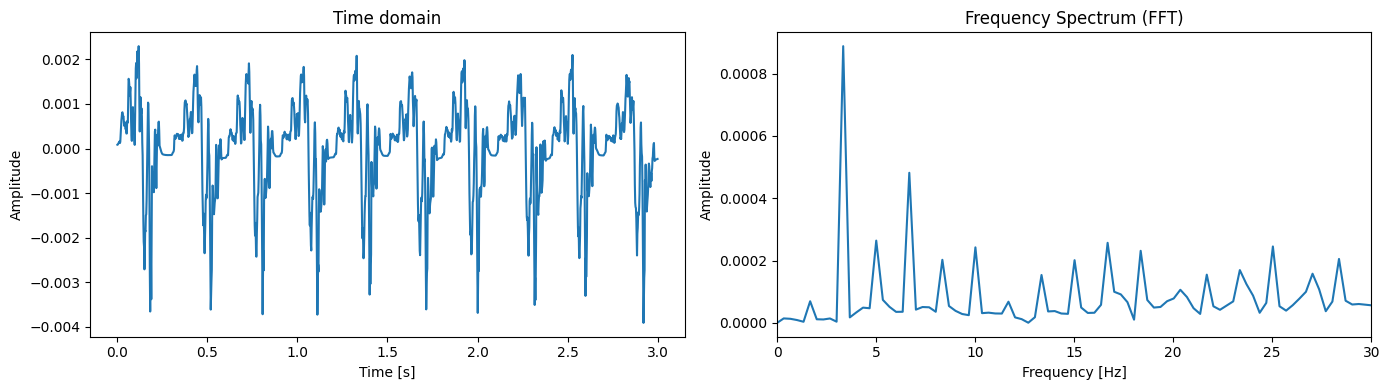

In [14]:
from scipy.fftpack import fft
#SENAL CENTRADA EN 0 (EJEY)
f_values1, fft_values1 = get_fft_values(signal-np.mean(signal), T, N, fs)
ta = np.linspace(0, t, num=N)
print(len(ta))
fig, axarr = plt.subplots(nrows=1, ncols=2, figsize=(14,4))
axarr[0].plot(ta, signal-np.mean(signal))
axarr[0].set_title("Time domain")
axarr[0].set_xlabel("Time [s]")
axarr[0].set_ylabel("Amplitude")

axarr[1].plot(f_values1, fft_values1)
axarr[1].set_title("Frequency Spectrum (FFT)")
axarr[1].set_xlabel("Frequency [Hz]")
axarr[1].set_xlim(0,30)
axarr[1].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

TO CONVERT FROM SCALE TO FREQUENCY --> fa = fc / a
* fa = pseudo-freq
* fc = central freq of the mother wavelet
* a = scaling factor

LARGE a (longer wavelet) --> lower freq
small a (narrower wavelet) --> HIGHER freq


-------> pywt.scale2frequency(wavelet, scale, precision=8) # precision 8 by default


In [15]:
print(pywt.families(short=False))

['Haar', 'Daubechies', 'Symlets', 'Coiflets', 'Biorthogonal', 'Reverse biorthogonal', 'Discrete Meyer (FIR Approximation)', 'Gaussian', 'Mexican hat wavelet', 'Morlet wavelet', 'Complex Gaussian wavelets', 'Shannon wavelets', 'Frequency B-Spline wavelets', 'Complex Morlet wavelets']


A wavelet must have:
1) FINITE ENERGY --> localized in time and freq
2) ZERO MEAN --> in the time domain (to be integrable and have inverse)

/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alumnos/mburgosc/anaconda3/envs/my_env/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


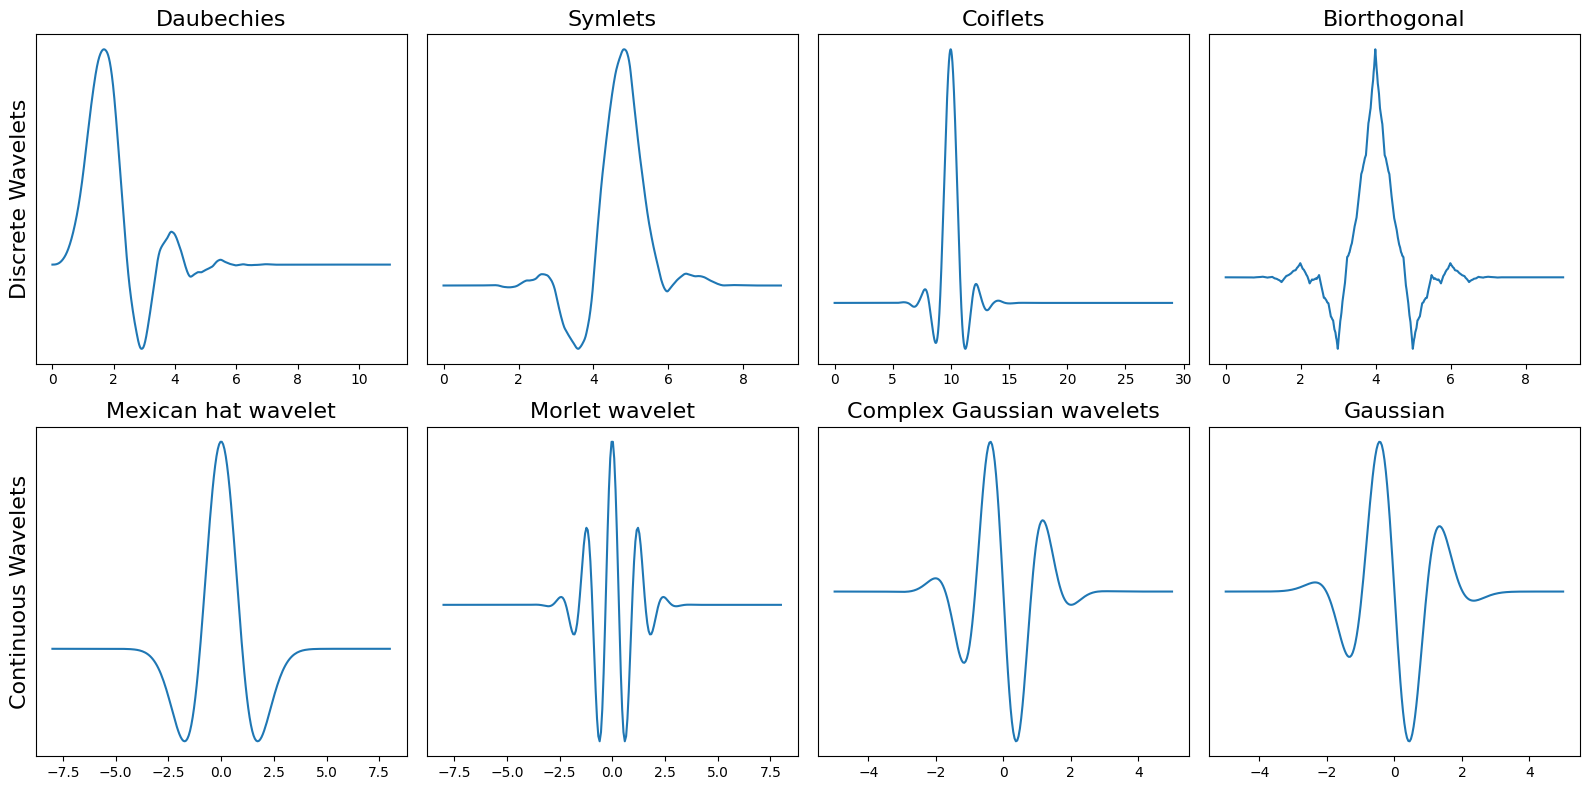

In [16]:
discrete_wavelets = ['db6', 'sym5', 'coif5', 'bior2.4']
continuous_wavelets = ['mexh', 'morl', 'cgau5', 'gaus5']

list_list_wavelets = [discrete_wavelets, continuous_wavelets]
list_funcs = [pywt.Wavelet, pywt.ContinuousWavelet]

fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(16,8))
for ii, list_wavelets in enumerate(list_list_wavelets):
    func = list_funcs[ii]
    row_no = ii
    for col_no, waveletname in enumerate(list_wavelets):
        wavelet = func(waveletname)
        family_name = wavelet.family_name
        biorthogonal = wavelet.biorthogonal
        orthogonal = wavelet.orthogonal
        symmetry = wavelet.symmetry
        if ii == 0:
            _ = wavelet.wavefun()
            wavelet_function = _[0]
            x_values = _[-1]
        else:
            wavelet_function, x_values = wavelet.wavefun()
        if col_no == 0 and ii == 0:
            axarr[row_no, col_no].set_ylabel("Discrete Wavelets", fontsize=16)
        if col_no == 0 and ii == 1:
            axarr[row_no, col_no].set_ylabel("Continuous Wavelets", fontsize=16)
        axarr[row_no, col_no].set_title("{}".format(family_name), fontsize=16)
        axarr[row_no, col_no].plot(x_values, wavelet_function)
        axarr[row_no, col_no].set_yticks([])
        axarr[row_no, col_no].set_yticklabels([])

plt.tight_layout()
plt.show()

['db1', 'db2', 'db3', 'db4', 'db5', 'db6']


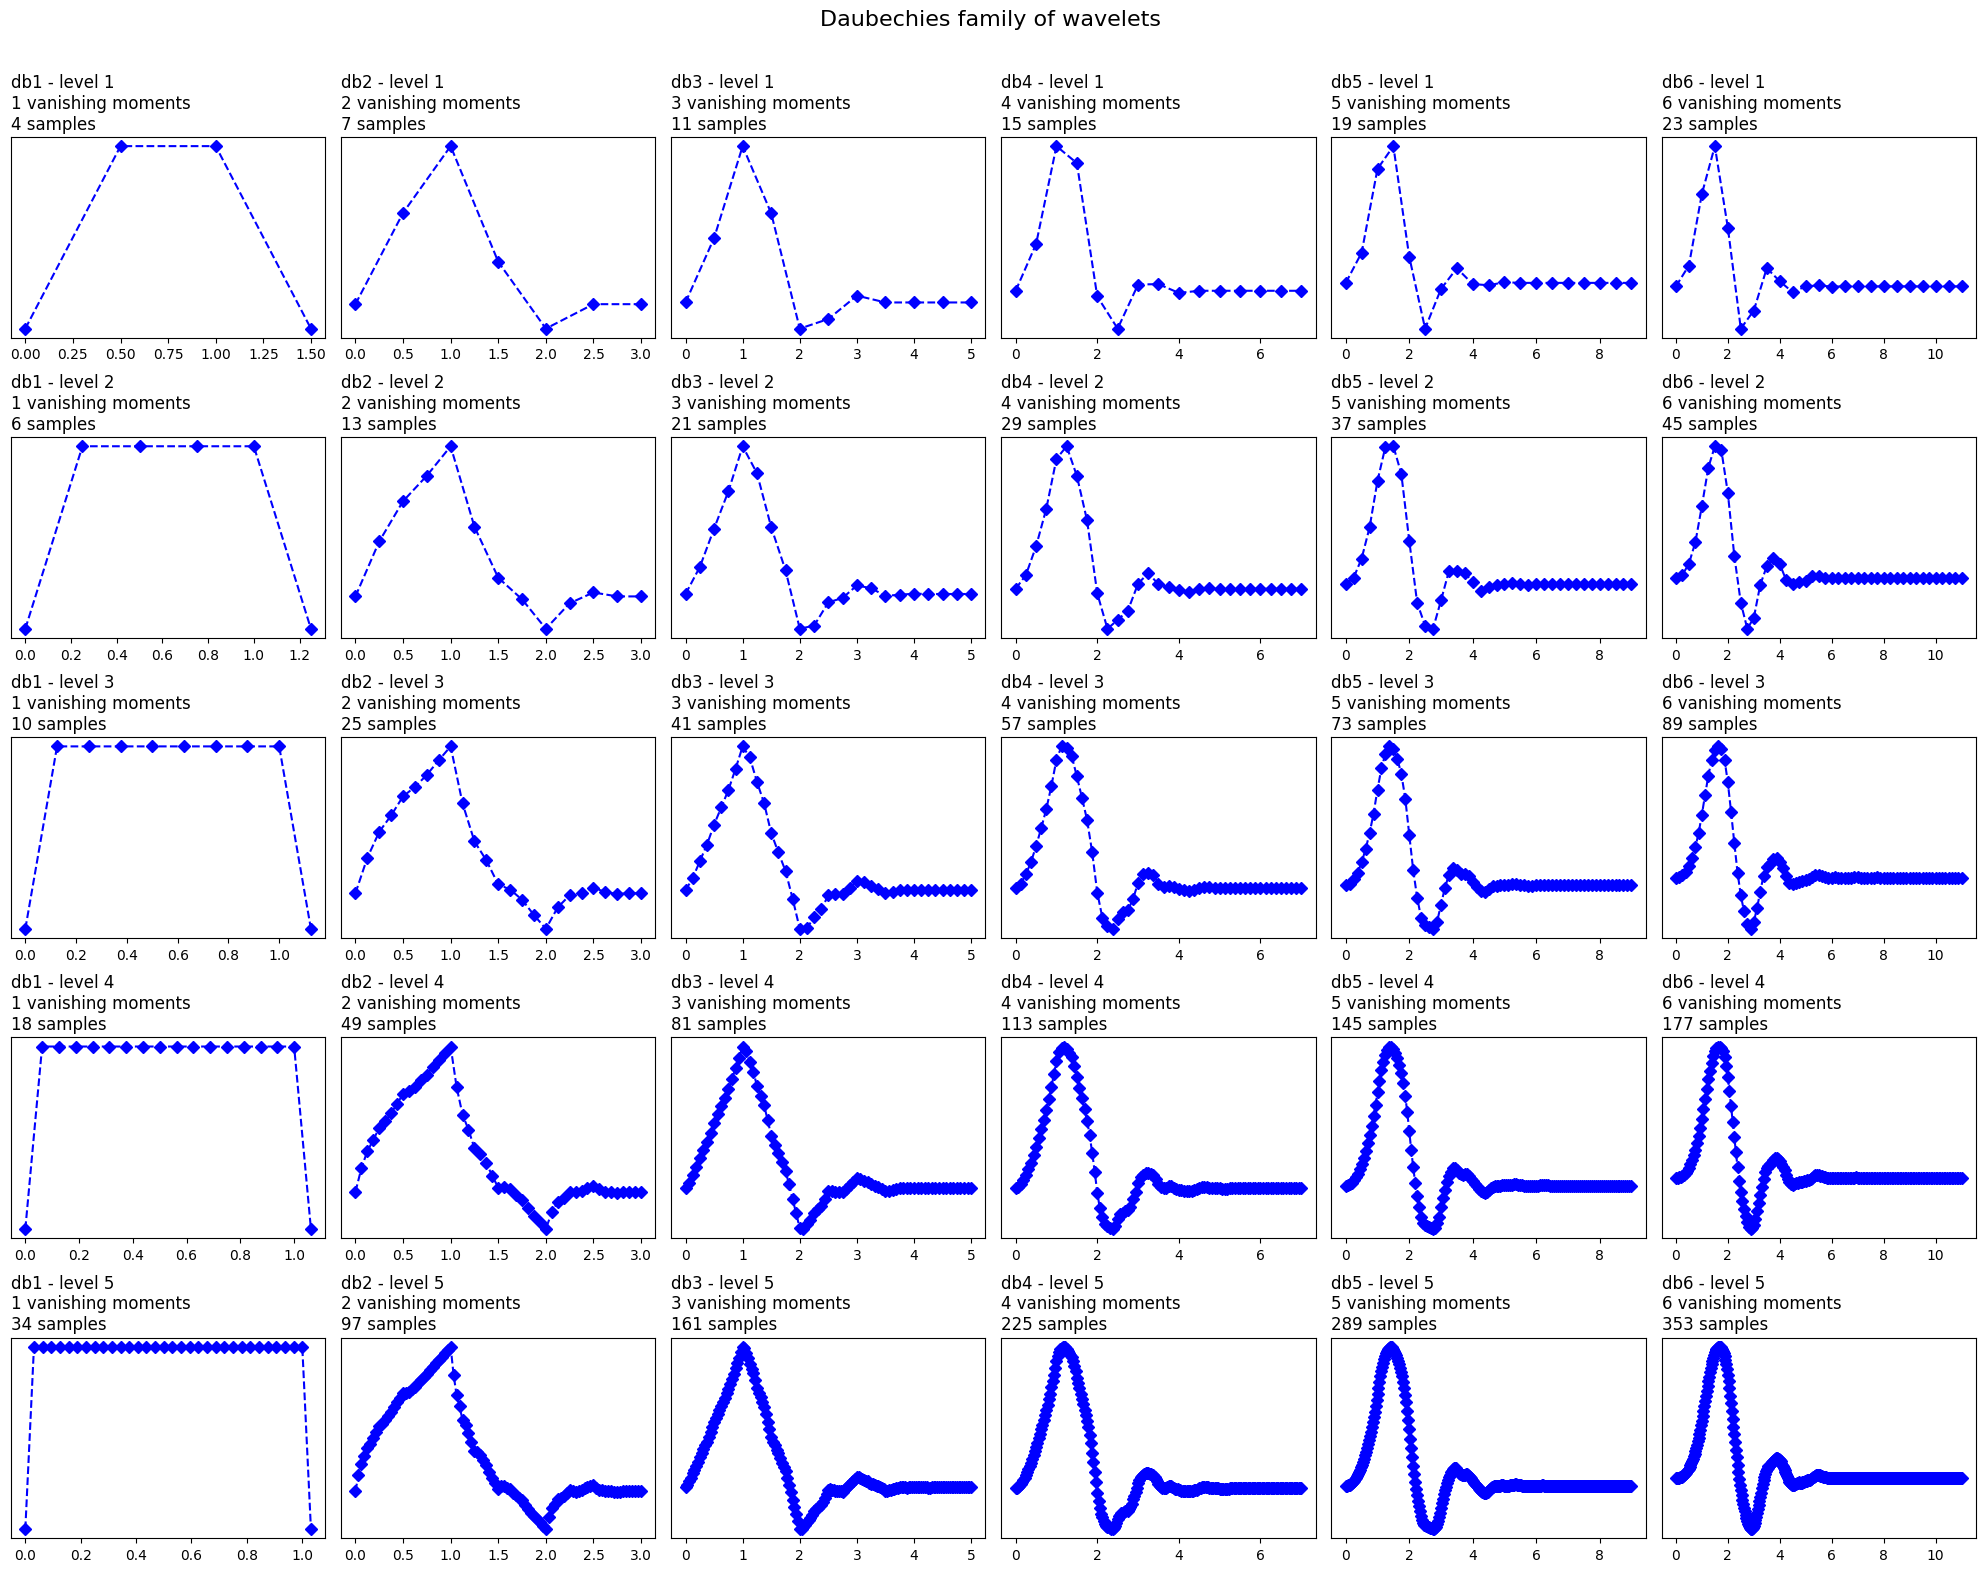

In [17]:

db_wavelets = pywt.wavelist('db')[:6]
print(db_wavelets)
#*** ['db1', 'db2', 'db3', 'db4', 'db5']

fig, axarr = plt.subplots(ncols=6, nrows=5, figsize=(20,16))
fig.suptitle('Daubechies family of wavelets', fontsize=16)
for col_no, waveletname in enumerate(db_wavelets):
    wavelet = pywt.Wavelet(waveletname)
    no_moments = wavelet.vanishing_moments_psi
    family_name = wavelet.family_name
    for row_no, level in enumerate(range(1,6)):
        wavelet_function, scaling_function, x_values = wavelet.wavefun(level = level)
        axarr[row_no, col_no].set_title("{} - level {}\n{} vanishing moments\n{} samples".format(
            waveletname, level, no_moments, len(x_values)), loc='left')
        axarr[row_no, col_no].plot(x_values, wavelet_function, 'bD--')
        axarr[row_no, col_no].set_yticks([])
        axarr[row_no, col_no].set_yticklabels([])
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

max decomposition level ----> pywt.dwt_max_level(data_len, filter_len)

* as num of vanishing moments increases --> polynom degree of the wavelet increases = SMOOTHER
* as the level of decomposition increases --> the num of samples the wavelet is expressed in also increases

time 1500
1500
1500


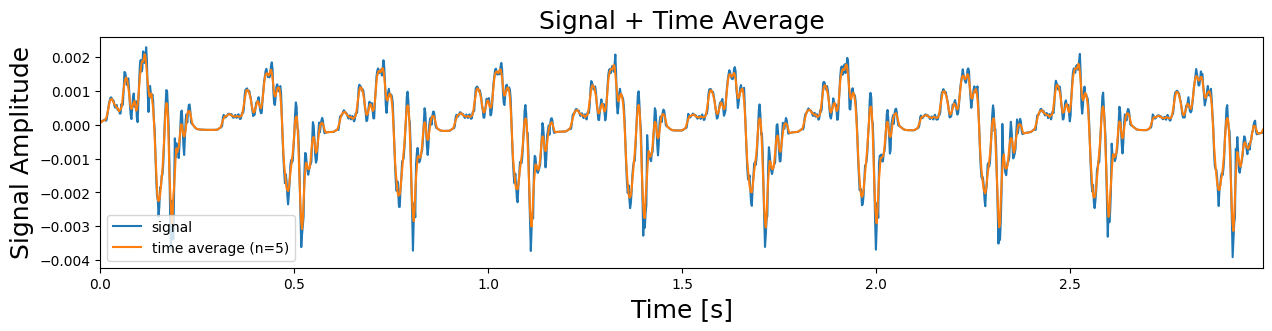

0.002
1.0379263985004007e-06
750
[2.41410330e-40 1.02839544e-10 8.63316376e-11 4.22247230e-11
 6.49623901e-12 2.40809119e-09 6.73437816e-11 6.02527910e-11
 1.00270351e-10 7.51238658e-12 3.94242133e-07 1.55406932e-10
 5.73082455e-10 1.19674323e-09 1.10423294e-09 3.48458975e-08
 2.72683407e-09 1.32844543e-09 6.25061921e-10 6.36483060e-10
 1.16012227e-07 9.06119291e-10 1.29461093e-09 1.25115156e-09
 6.37345816e-10 2.04811748e-08 1.46728324e-09 7.43004107e-10
 4.04875609e-10 3.07029278e-10 2.93665779e-08 4.88930070e-10
 5.38557824e-10 4.57742306e-10 4.47694080e-10 2.31086083e-09
 1.55658462e-10 7.14969020e-11 1.37743571e-13 1.65152805e-10
 1.18051220e-08 6.74611118e-10 7.17909671e-10 4.52546956e-10
 4.21590438e-10 2.02373916e-08 1.21129405e-09 5.09923931e-10
 5.28416704e-10 1.67679402e-09 3.30065284e-08 4.98241964e-09
 4.17259607e-09 2.20952156e-09 5.32835473e-11 2.67460065e-08
 2.69968361e-09 1.20870107e-09 1.30619222e-09 2.42116736e-09
 3.07255619e-09 5.64639039e-09 3.43648947e-09 1.1123

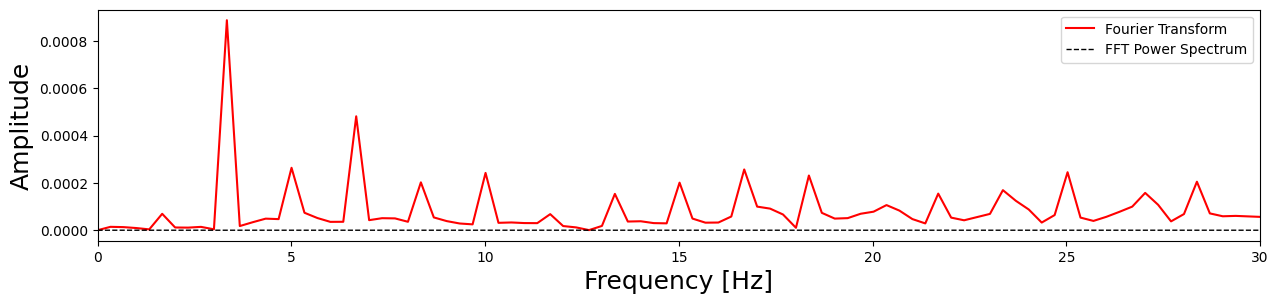

['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']
0.002


(0.0, 40.0)

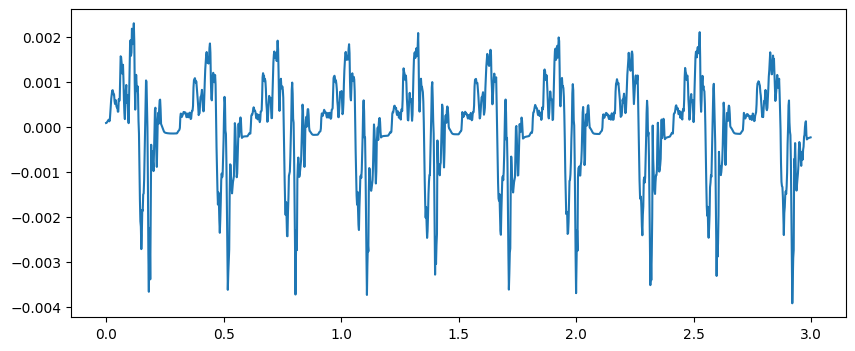

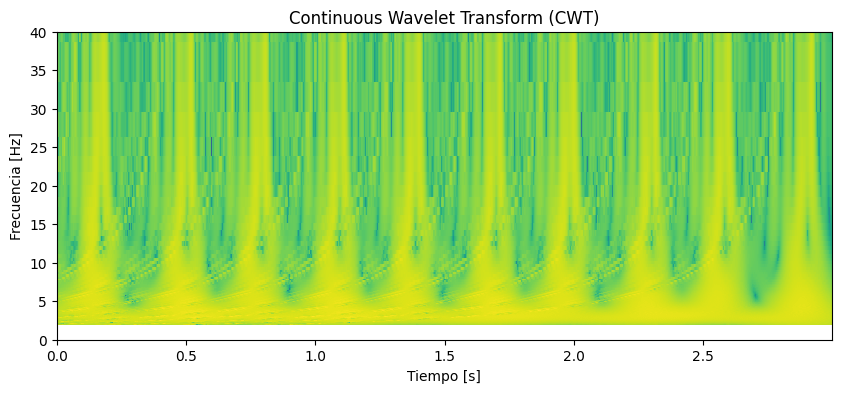

In [18]:
def plot_wavelet(time, signal, scales, 
                 waveletname = 'cmor', 
                 cmap = plt.cm.seismic, 
                 title = 'Wavelet Transform (Power Spectrum) of signal', 
                 ylabel = 'Period (years)', 
                 xlabel = 'Time'):
    
    dt = time[1] - time[0]
    print(dt)
    [coefficients, frequencies] = pywt.cwt(signal, scales, waveletname, dt)
    print(frequencies)
    power = (abs(coefficients)) ** 2
    period = 1. / frequencies
    levels = [0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8]
    contourlevels = np.log2(levels)
    
    fig, ax = plt.subplots(figsize=(15, 10))
    im = ax.contourf(time, frequencies, np.log2(power), contourlevels, extend='both',cmap=cmap)
    
    ax.set_title(title, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=18)
    
    yticks = 2**np.arange(np.ceil(np.log2(period.min())), np.ceil(np.log2(period.max())))
    ax.set_yticks(np.log2(yticks))
    ax.set_yticklabels(yticks)
    ax.invert_yaxis()
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], -1)
    
    cbar_ax = fig.add_axes([0.95, 0.5, 0.03, 0.25])
    fig.colorbar(im, cax=cbar_ax, orientation="vertical")
    plt.show()


def get_ave_values(time, signal, average_over):
    kernel = np.ones(average_over) / average_over  # Ventana de promediado
    signal_ave = np.convolve(signal, kernel, mode='same')  # Mantiene tamaño original
    print(len(signal_ave))
    return time, signal_ave  # No es necesario recortar time


def plot_signal_plus_average(time, signal, average_over = 5):
    fig, ax = plt.subplots(figsize=(15, 3))
    time_ave, signal_ave = get_ave_values(time, signal, average_over)
    ax.plot(time, signal, label='signal')
    ax.plot(time_ave, signal_ave, label = 'time average (n={})'.format(5))
    ax.set_xlim([time[0], time[-1]])
    ax.set_xlabel('Time [s]', fontsize=18)
    ax.set_ylabel('Signal Amplitude', fontsize=18)
    ax.set_title('Signal + Time Average', fontsize=18)
    ax.legend()
    plt.show()
    
def get_fft_values(y_values, T, N, f_s):
    f_values = np.linspace(0.0, 1.0/(2.0*T), N//2)
    fft_values_ = fft(y_values)
    fft_values = 2.0/N * np.abs(fft_values_[0:N//2])
    print(len(f_values))
    return f_values, fft_values

def plot_fft_plus_power(time, signal):
    dt = time[1] - time[0]
    print(dt)
    N = len(signal)
    fs = 1/dt
    
    
    fig, ax = plt.subplots(figsize=(15, 3))
    variance = np.std(signal)**2
    print(variance)
    f_values, fft_values = get_fft_values(signal-np.mean(signal), dt, N, fs)   #cambie esto y colapsó pero no entiendo que es dt que estaba en lugar de T
    fft_power = (variance * abs(fft_values) ** 2)/ np.sum(abs(fft_values) ** 2)     # FFT power spectrum
    print(fft_power)
    ax.plot(f_values, fft_values, 'r-', label='Fourier Transform')
    ax.plot(f_values, fft_power, 'k--', linewidth=1, label='FFT Power Spectrum')
    ax.set_xlabel('Frequency [Hz]', fontsize=18)
    ax.set_xlim(0,30)
    #ax.set_ylim(0,0.00001)
    ax.set_ylabel('Amplitude', fontsize=18)
    ax.legend()
    plt.show()

t0=0
dt=0.002
time = np.arange(0, N) * dt + t0
print('time',len(time))
print(len(signal))

scales = np.arange(1, 128)
t = np.arange(len(signal))/fs

plot_signal_plus_average(t, signal-np.mean(signal))
plot_fft_plus_power(t, signal-np.mean(signal))
#plot_wavelet(time, signal, scales)


print(pywt.wavelist(kind='continuous'))


plt.figure(figsize=(10, 4))
plt.plot(t, signal-np.mean(signal))
plt.figure(figsize=(10, 4))
dt = t[1] - t[0]
print(dt)
[coefficients, frequencies] = pywt.cwt(signal-np.mean(signal), scales, 'cmor1.0-0.5', dt)
power = (abs(coefficients)) ** 2
plt.title("Continuous Wavelet Transform (CWT)")
plt.pcolormesh(t, frequencies, np.log10(power))
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.ylim(0,40)


We start with SMALL SCALES --> correspond with HIGH FREQUENCIES (analyzing these)
Then we increase the scale by a factor of 2 --> lowering the freqs by the same factor (lower freqs analyzed)

MAX DECOMPOSITION LEVEL --> At ecah substage the num of samples are also reduced with a factor of 2. Bec of this downsampling, at ome stage the num of samples will become samller than the length of the wavelet fiter used --> getting at this pint the MAX DECOMPOSITION LEVEL


* APPROXIMATION COEFFS = repre the output of the LPF (averaging filter) of the DWT 
* DETAIL COEFFS = repr the output of the HPF (diference filter) of the DWT


The idea of analyzing the signal on DIFFERENT SCALES is known as --> MULTIRESOLUTION/MULTISCALE ANALYSIS 
Decomposing the signal is also known as --> MULTIRESOLUTION DECOMPOSITION (SUB-BAND CODING)

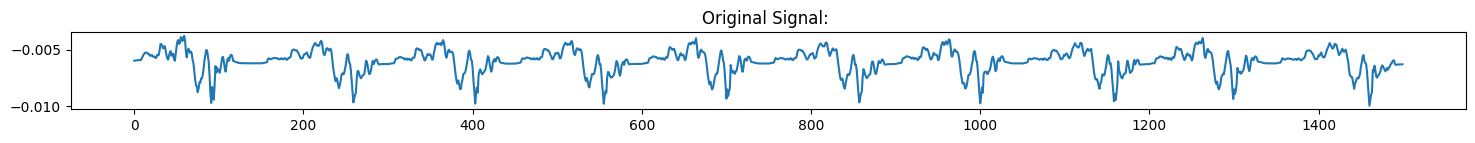

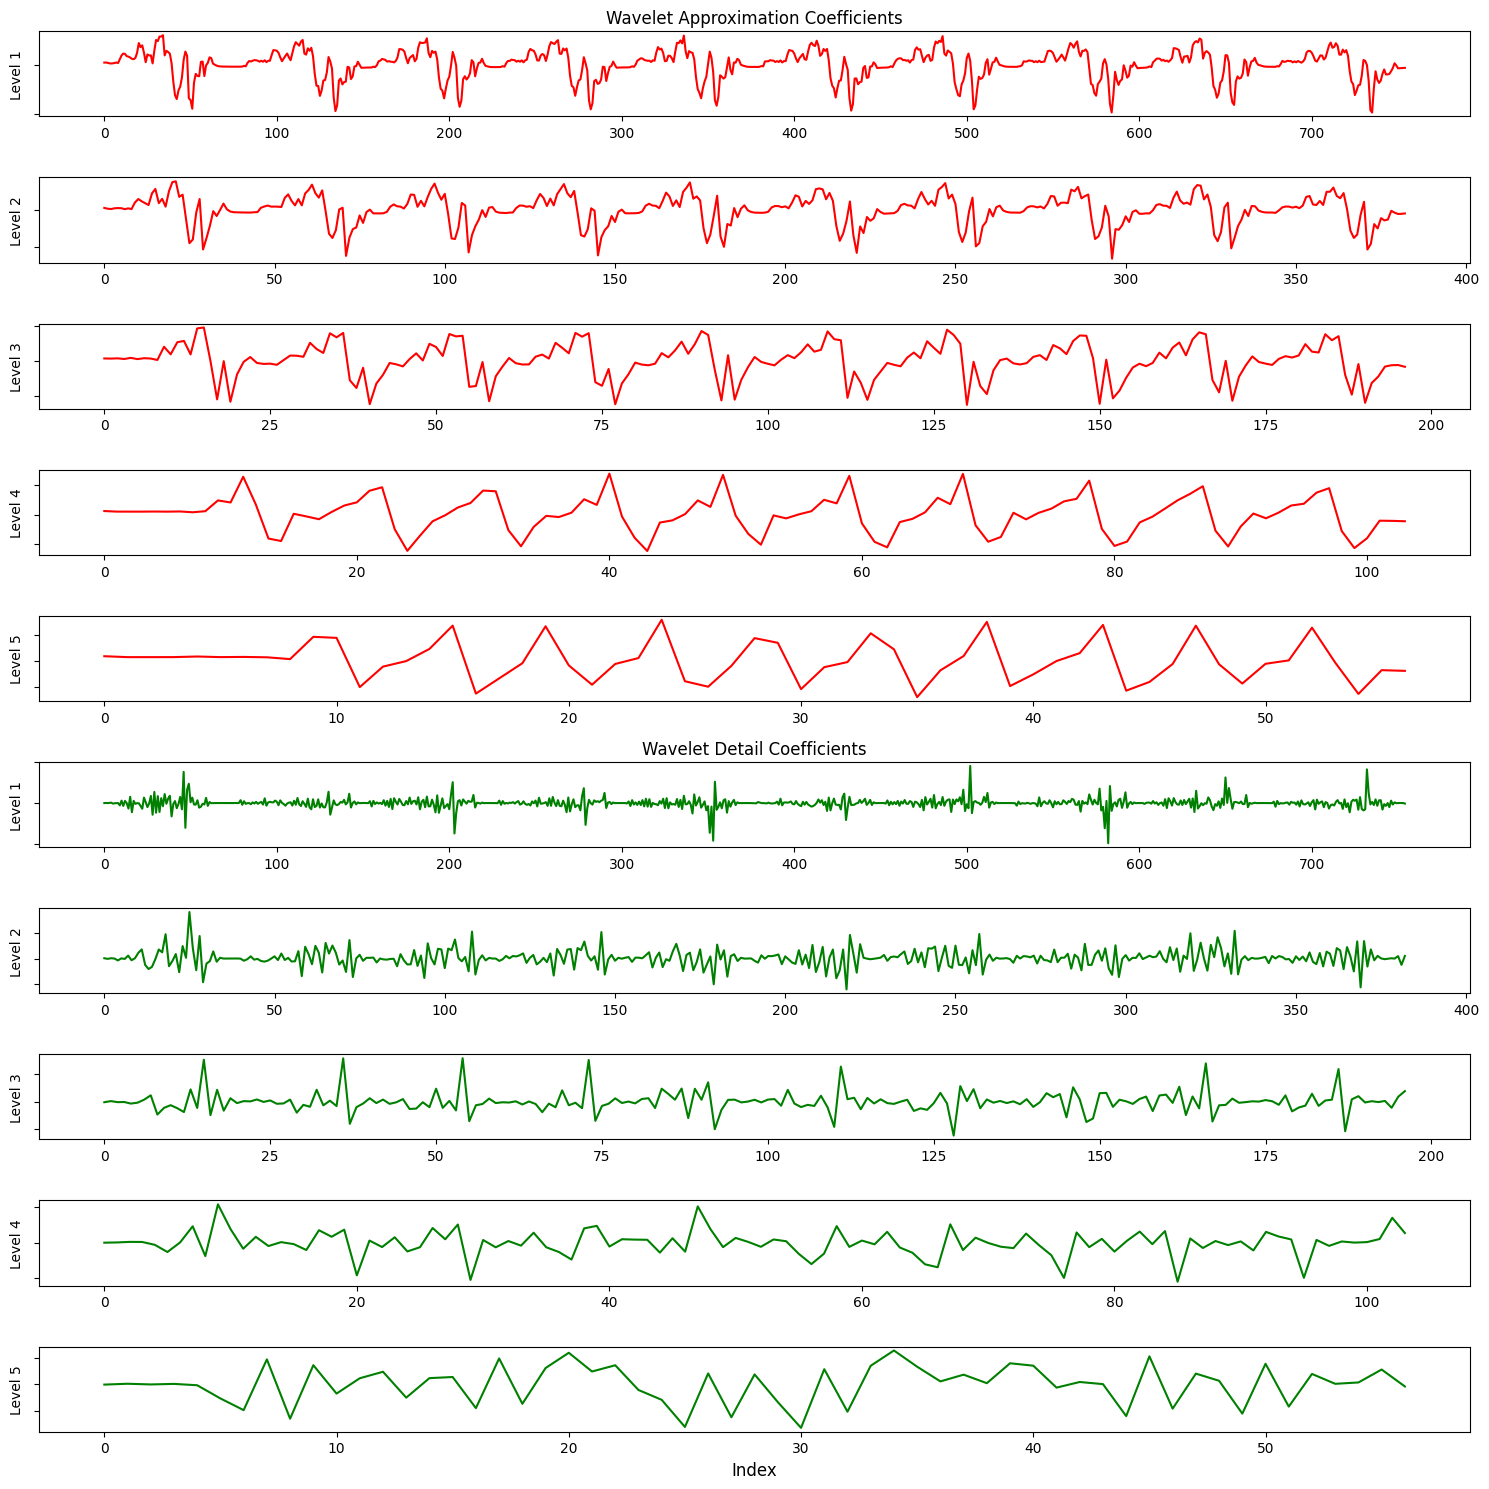

In [19]:
import pywt

x = np.linspace(0, 1, num=2048)
signal =bsps_64_all_models[0][0,:]
    
fig, ax = plt.subplots(figsize=(18,1))
ax.set_title("Original Signal: ")
ax.plot(signal)
#ax.axis('off')
plt.show()
    
data = signal-np.mean(signal)
waveletname = 'db6'

fig, axarr = plt.subplots(nrows=10, ncols=1, figsize=(15, 15))  # 10 filas para separar bien

approx_coeffs = []  # Lista para guardar los coeficientes de aproximación
detail_coeffs = []  # Lista para guardar los coeficientes de detalle

for _ in range(5):
    data, coeff_d = pywt.dwt(data, waveletname)
    approx_coeffs.append(data)
    detail_coeffs.append(coeff_d)

# Dibujar las aproximaciones en las primeras 5 filas
for ii in range(5):
    axarr[ii].plot(approx_coeffs[ii], 'r', label=f"Level {ii + 1} Approximation")
    axarr[ii].set_ylabel(f"Level {ii + 1}", fontsize=10)
    axarr[ii].set_yticklabels([])

# Dibujar los detalles en las últimas 5 filas
for ii in range(5):
    axarr[ii + 5].plot(detail_coeffs[ii], 'g', label=f"Level {ii + 1} Detail")
    axarr[ii + 5].set_ylabel(f"Level {ii + 1}", fontsize=10)
    axarr[ii + 5].set_yticklabels([])

# Títulos en la primera fila de cada tipo
axarr[0].set_title("Wavelet Approximation Coefficients", fontsize=12)
axarr[5].set_title("Wavelet Detail Coefficients", fontsize=12)

# Etiqueta en el último gráfico
axarr[-1].set_xlabel("Index", fontsize=12)

plt.tight_layout()
plt.show()

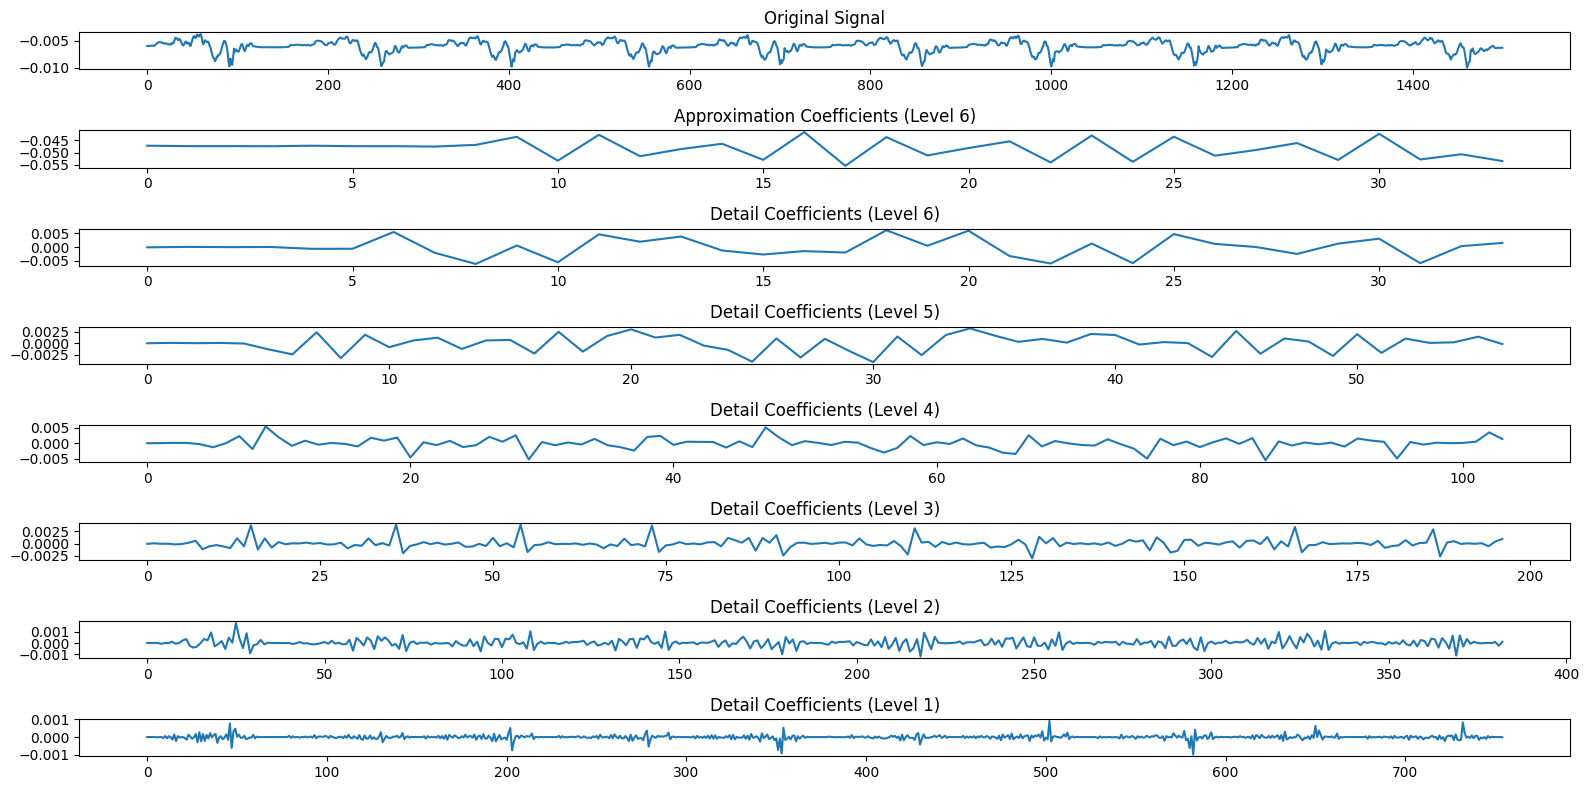

In [20]:
#SAME AS BEFORE BUT USING WAVEDEC() --> NOTEBOOK OSCAR



#perform dwt with sym4 and 6 levels

# Perform the DWT decomposition
wavelet = 'db6'  # Symlet wavelet of order 4
level = 6  # Decomposition level

coeffs = pywt.wavedec(signal.flatten(), wavelet, level=6)

approximation = coeffs[0]
details = coeffs[1:]

# Plot the original signal
plt.figure(figsize=(16, 8))
plt.subplot(8, 1, 1)
plt.plot(signal.flatten())
plt.title("Original Signal")

# Plot coefficients
plt.subplot(8, 1, 2)
plt.plot(approximation)
plt.title("Approximation Coefficients (Level 6)")

for i, detail in enumerate(details, start=1):
    plt.subplot(8, 1, i + 2)
    plt.plot(detail)
    plt.title(f"Detail Coefficients (Level {level + 1 - i})")

plt.tight_layout()
plt.show()

pywt.dwt(): Realiza una Transformada Wavelet Discreta en 1D (puede ser utilizada en señales unidimensionales).

* cA (coeficientes de aproximación): Estos representan las bajas frecuencias de la señal.
* cD (coeficientes de detalles): Estos representan las altas frecuencias (detalles de la señal).

In [ ]:
import pywt
import pywt.data
cA, cD = pywt.dwt(bsps_64_all_models[0][0,:], 'db6', level = 5)
print(len(cA))
print(len(cD))

In [ ]:

# Crear una señal de ejemplo (por ejemplo, una señal de sinusoidal)
fs = 500  # frecuencia de muestreo
t = np.linspace(0, 1, fs)
signal = bsps_64_all_models[0][0,:]  # señal compuesta

# Aplicar la DWT utilizando Daubechies 6 (db6) en 5 niveles
coeffs = pywt.wavedec(signal, 'db6', level=5)
cA2, cD5, cD4, cD3, cD2, cD1 = coeffs
# Los coeficientes de 'wavedec' incluyen: 
# - cA5 (aproximación de nivel 5)
# - cD5, cD4, cD3, cD2, cD1 (detalles en los niveles 5, 4, 3, 2, 1)
# Los coeficientes cD1 a cD5 son los coeficientes de detalle en cada nivel de descomposición.
print(cD5.shape)
print(len(cD5))
print(cD4.shape)
print(cD3.shape)
print(cD2.shape)
print(cD1.shape)

# Plot the signal and the wavelet coefficients  
plt.figure(figsize=(10, 6))
#plt.plot(cA2, label='Level 5 Approximation', alpha=0.7)  # Aproximación de nivel 5
plt.plot(cD5, label='Level 5 Detail', alpha=0.7)         # Detalle de nivel 5
plt.plot(cD4, label='Level 4 Detail', alpha=0.7)         # Detalle de nivel 4
plt.plot(cD3, label='Level 3 Detail', alpha=0.7)         # Detalle de nivel 3
plt.plot(cD2, label='Level 2 Detail', alpha=0.7)         # Detalle de nivel 2
plt.plot(cD1, label='Level 1 Detail', alpha=0.7)         # Detalle de nivel 1
#plt.legend(loc='upper right')
plt.title("DWT Coefficients")
plt.show()


In [ ]:
fig, axes = plt.subplots(len(coeffs), 1, figsize=(10, 6))

for i, ax in enumerate(axes):
    ax.plot(coeffs[i])
    ax.set_title(f'Coeficiente {"Aproximación" if i == 0 else f"Detalle {len(coeffs)-i}"}')
    ax.grid(True)

plt.tight_layout()
plt.show()